# Spatial Join
- Spatial joins are operations that combine data from two or more spatial data sets based on their geometric relationship.

- Spatial join operations require two input parameters: the predicament, i.e., the geometric condition that needs to be met between two geometries, and the join-type: whether only rows with matching geometries are kept, or all of one input table’s rows, or all records.

Geopandas (using shapely to implement geometric relationships) supports a standard set of geometric predicates, that is similar to most GIS analysis tools and applications:

- intersects

- contains

- within

- touches

- crosses

- overlaps

Geometric predicaments are expressed as verbs, so they have an intuitive meaning. See the shapely user manual for a detailed description of each geometric predicate.

In terms of the join-type, geopandas implements three different options:

- left: keep all records of the left data frame, fill with empty values if no match, keep left geometry column

- right: keep all records of the left data frame, fill with empty values if no match, keep right geometry column

- inner: keep only records of matching records, keep left geometry column

In [2]:
import pathlib
NOTEBOOK_PATH = pathlib.Path().resolve()
DATA_DIRECTORY = NOTEBOOK_PATH / "data"

In [9]:
import geopandas

addresses = geopandas.read_file(DATA_DIRECTORY / "addresses.gpkg")

population_grid = geopandas.read_file(
    "https://avoidatastr.blob.core.windows.net/avoindata/AvoinData/"
    "6_Asuminen/Vaestotietoruudukko/Shp/Vaestotietoruudukko_2021_shp.zip"
)

/home/faustino/miniconda3/envs/autogis/lib/python3.11/site-packages/pyogrio/geopandas.py:382: UserWarning: More than one layer found in 'addresses.gpkg': 'addresses' (default), 'addresses_with_population_data'. Specify layer parameter to avoid this warning.
  result = read_func(


In [10]:
population_grid.head()

,INDEX,ASUKKAITA,ASVALJYYS,IKA0_9,IKA10_19,IKA20_29,IKA30_39,IKA40_49,IKA50_59,IKA60_69,IKA70_79,IKA_YLI80,geometry
0,688,5,50.60,99,99,99,99,99,99,99,99,99,"POLYGON ((25472499.995 6689749.005, 25472499.9..."
1,703,7,36.71,99,99,99,99,99,99,99,99,99,"POLYGON ((25472499.995 6685998.998, 25472499.9..."
2,710,8,44.50,99,99,99,99,99,99,99,99,99,"POLYGON ((25472499.995 6684249.004, 25472499.9..."
3,711,7,64.14,99,99,99,99,99,99,99,99,99,"POLYGON ((25472499.995 6683999.005, 25472499.9..."
4,715,11,41.09,99,99,99,99,99,99,99,99,99,"POLYGON ((25472499.995 6682998.998, 25472499.9..."


In [11]:
population_grid = population_grid[["ASUKKAITA", "geometry"]]
population_grid = population_grid.rename(columns={"ASUKKAITA": "population"})
population_grid.head()

,population,geometry
0,5,"POLYGON ((25472499.995 6689749.005, 25472499.9..."
1,7,"POLYGON ((25472499.995 6685998.998, 25472499.9..."
2,8,"POLYGON ((25472499.995 6684249.004, 25472499.9..."
3,7,"POLYGON ((25472499.995 6683999.005, 25472499.9..."
4,11,"POLYGON ((25472499.995 6682998.998, 25472499.9..."


In [12]:
population_grid["population_density"] = (
    population_grid["population"]
    / (population_grid.area / 1_000_000)
)
population_grid.head()


,population,geometry,population_density
0,5,"POLYGON ((25472499.995 6689749.005, 25472499.9...",80.001048
1,7,"POLYGON ((25472499.995 6685998.998, 25472499.9...",112.001467
2,8,"POLYGON ((25472499.995 6684249.004, 25472499.9...",128.001677
3,7,"POLYGON ((25472499.995 6683999.005, 25472499.9...",112.001467
4,11,"POLYGON ((25472499.995 6682998.998, 25472499.9...",176.002305


### Join input layers

In [14]:
assert addresses.crs == population_grid.crs, "CRS are not identical"

AssertionError: CRS are not identical

In [15]:
population_grid = population_grid.to_crs(addresses.crs)

In [16]:
addresses_with_population_data = addresses.sjoin(
    population_grid,
    how="left",
    predicate="within"
)
addresses_with_population_data.head()

,address,geometry,index_right,population,population_density
0,"Ruoholahti, 14, Itämerenkatu, Ruoholahti, Läns...",POINT (24.91556 60.1632),3262.0,505.0,8080.105832
1,"1, Kampinkuja, Kamppi, Eteläinen suurpiiri, He...",POINT (24.93009 60.16846),3381.0,172.0,2752.036046
2,"Espresso House, 8, Kaivokatu, Keskusta, Kluuvi...",POINT (24.94153 60.17016),3504.0,43.0,688.009011
3,"Hermannin rantatie, Verkkosaari, Kalasatama, S...",POINT (24.97853 60.1905),NaN,NaN,NaN
4,"9, Tyynenmerenkatu, Jätkäsaari, Länsisatama, E...",POINT (24.92169 60.15667),3310.0,1402.0,22431.538035


That looks great! We now have an address data set with population density information attached to it.

As a final task, let’s look at how to plot data using a graduated cartographic visualisation scheme.

The geopandas.GeoDataFrame.plot() method can vary the map colours depending on a column’s values by passing its name as a named argument column. On top of that, the method accepts many arguments to influence the style of the map. Among them are scheme and cmap that define the categorisation scheme, and the colour map used. Many more arguments are passed through to matplotlib, such as markersize to set the size of point symbols, and facecolor to set the colour of polygon areas. To draw a legend, set legend to True, to set the size of the figure, pass a tuple (with values in inch) as figsize.

Text(0.5, 1.0, 'Population density around address points')

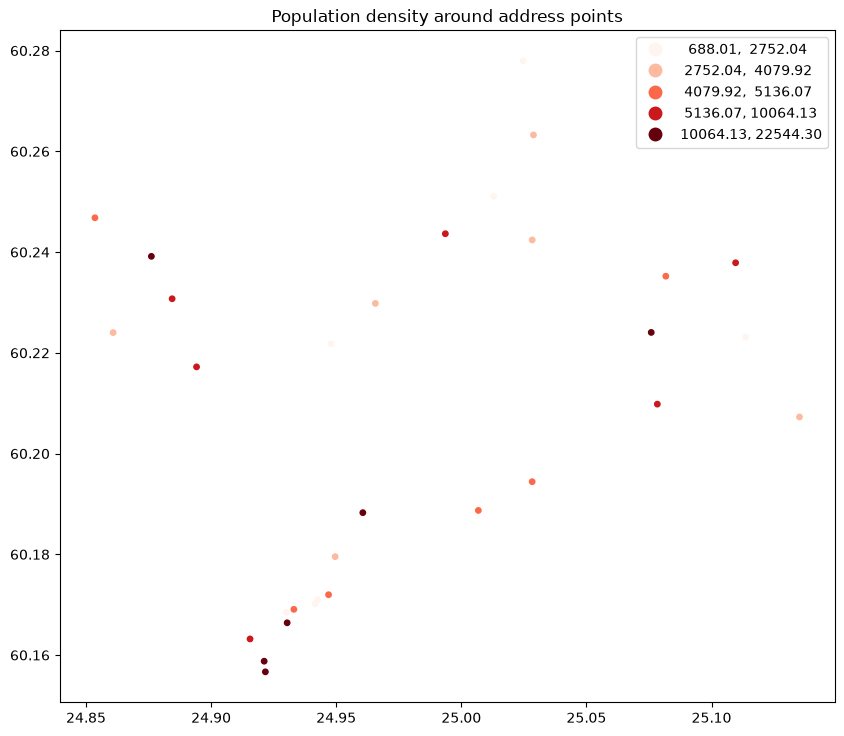

In [17]:
ax = addresses_with_population_data.plot(
    figsize=(10, 10),
    column="population_density",
    cmap="Reds",
    scheme="quantiles",
    markersize=15,
    legend=True
)
ax.set_title("Population density around address points")

#### We can apply the same arguments to plot a population density map using the entire population_grid data set:

Text(0.5, 1.0, 'Population density in the Helsinki metropolitan area')

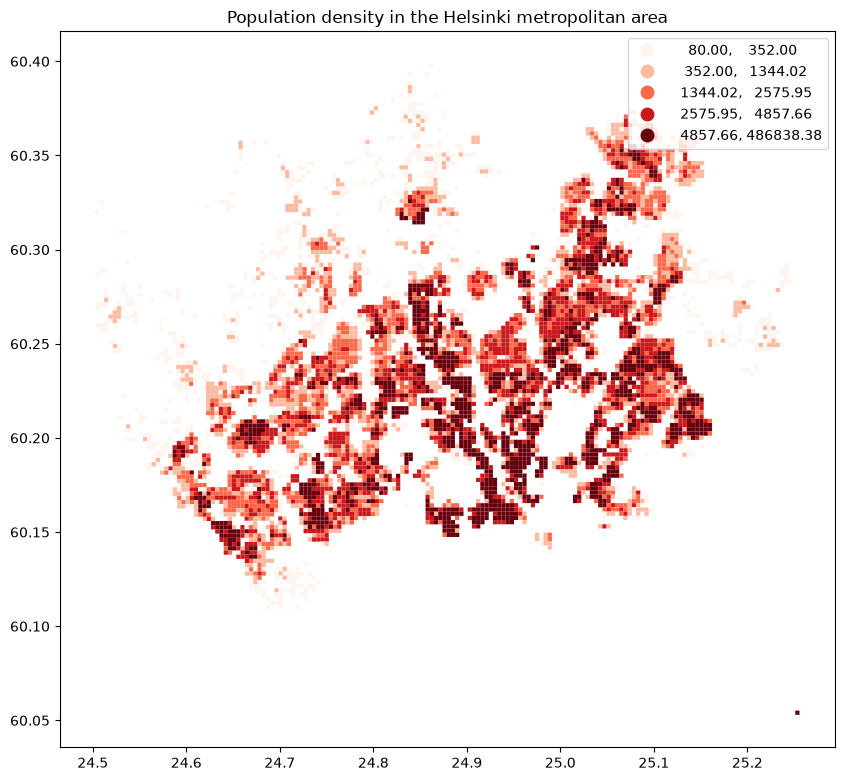

In [18]:
ax = population_grid.plot(
    figsize=(10, 10),
    column="population_density",
    cmap="Reds",
    scheme="quantiles",
    legend=True
)
ax.set_title("Population density in the Helsinki metropolitan area")

In [19]:
addresses_with_population_data.to_file(
    DATA_DIRECTORY / "addresses.gpkg",
    layer="addresses_with_population_data"
)